# A3 Epidemic spreading on complex networks
**Student:** Omar Morales Ortega

---

## Epidemic Spreading: SIS Model on Complex Networks
This notebook implements a Monte Carlo (MC) simulation of the Susceptible-Infected-Susceptible (SIS) model. We explore the transition of the disease across different network topologies: Erdös-Rényi (ER) and Barábasi-Albert (BA).

### Objectives:
- Simulate the fraction of infected nodes $\rho$ in the stationary state.
- Analyze $\rho$ as a function of the infection probability $\lambda \in [0, 0.3]$.
- Compare results for different recovery probabilities $\mu$ ($0.2$ and $0.4$).
- Compare simulation results with the theoretical Microscopic Markov Chain Approach (MMCA).

### Dependencies and Global Parameters
Import libraries and set simulation parameters

In [16]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import time

# Simulation Parameters as per requirements
N = 1000
LAMBDAS = np.arange(0, 0.31, 0.01)
MUS = [0.2, 0.4]
N_REP = 50           # Number of repetitions to average results
T_MAX = 1000         # Total time steps
T_TRANS = 900        # Time steps to discard as transitory
INITIAL_INFECTED = 50 # Start with 50 nodes to avoid early extinction

### Network Generation
We generate four distinct networks of 1000 nodes each. For the BA networks, since the average degree $\langle k \rangle \approx 2m$, we set $m=2$ for $\langle k \rangle=4$ and $m=3$ for $\langle k \rangle=6$.

In [17]:
def get_networks(n=1000):
    networks = {
        "ER <k>=4": nx.erdos_renyi_graph(n, 4/(n-1)),
        "ER <k>=6": nx.erdos_renyi_graph(n, 6/(n-1)),
        "BA <k>=4": nx.barabasi_albert_graph(n, 2),
        "BA <k>=6": nx.barabasi_albert_graph(n, 3)
    }
    return networks

nets = get_networks(N)
print("Networks generated successfully.")

Networks generated successfully.


### The Monte Carlo Simulation Engine

#### SIS Dynamics Logic
The simulation follows these discrete-time rules:
 - Recovery: Each infected node recovers with probability $\mu$.
 - Infection: Each susceptible node checks its infected neighbors. If it has $k_{inf}$ infected neighbors, the probability of not being infected is $(1-\lambda)^{k_{inf}}$. Therefore, the probability of infection is:$$P_{inf} = 1 - (1 - \lambda)^{k_{inf}}$$
 
 We calculate $\rho$ by averaging the fraction of infected nodes over the last $T_{max} - T_{trans}$ steps across all repetitions.

In [ ]:
def simulate_sis(G, lambda_val, mu):
    n = G.number_of_nodes()
    nodes = list(G.nodes())
    rep_rhos = []

    for _ in range(N_REP):
        # Initial state: 0=S, 1=I
        state = np.zeros(n)
        inf_idx = np.random.choice(n, INITIAL_INFECTED, replace=False)
        state[inf_idx] = 1
        
        rho_history = []
        for t in range(T_MAX):
            new_state = state.copy()
            for i in range(n):
                if state[i] == 1: # Node is Infected
                    if np.random.random() < mu:
                        new_state[i] = 0
                else: # Node is Susceptible
                    inf_neighbors = sum(state[nb] for nb in G.neighbors(i))
                    if inf_neighbors > 0:
                        # Success if at least one infected neighbor transmits
                        # 1 - (1 - lambda)^k
                        p_inf = 1 - (1 - lambda_val)**inf_neighbors
                        if np.random.random() < p_inf:
                            new_state[i] = 1
            
            state = new_state
            # This handles the time-average (last 100 steps)
            if t >= T_TRANS:
                rho_history.append(np.mean(state))
        # This stores the average of those 100 steps for ONE realization
        rep_rhos.append(np.mean(rho_history))
    
    # This returns the final average over all 50 realizations (N_REP)
    return np.mean(rep_rhos)

### Theoretical Prediction (MMCA)
#### Microscopic Markov Chain Approach
To validate our simulation, we solve the MMCA fixed-point equation for each node $i$:$$p_i(t+1) = (1-q_i(t))(1-p_i(t)) + (1-\mu)p_i(t)$$where $q_i(t)$ is the probability that node $i$ is not infected by any neighbor:$$q_i(t) = \prod_{j \in \text{neigh}(i)} (1 - \lambda p_j(t))$$

In [ ]:
def run_mmca(G, lambda_val, mu, tol=1e-6, max_iter=500):
    """Microscopic Markov Chain Approach prediction."""
    n = G.number_of_nodes()
    # Adjacency matrix is required for vectorized neighborhood products
    adj = nx.to_numpy_array(G)
    p = np.full(n, 0.2)  # Initial probability guess for each node
    
    for _ in range(max_iter):
        # Calculate qi for all nodes: product(1 - lambda * p_j) for j in neighbors
        # We use log-sum-exp trick for numerical stability and speed
        # log(qi) = sum(log(1 - lambda * p_j))
        # This matrix multiplication (@) and log/exp is the 
        # computational version of the Product symbol (Q)
        log_qi = adj @ np.log(1 - lambda_val * p + 1e-15)
        qi = np.exp(log_qi)
        
        # SIS Fixed-point equation: p_i = (1 - qi)(1 - p_i) + (1 - mu)p_i
        p_next = (1 - qi) * (1 - p) + (1 - mu) * p
        
        # Check for convergence using the average difference
        if np.linalg.norm(p_next - p, ord=1) / n < tol:
            break
        p = p_next
        
    return np.mean(p)


### Main Execution Loop

#### Running the Simulations
Note: This step is computationally expensive. We iterate through each value of $\mu$, each network, and each $\lambda$. We store the results for both Monte Carlo and MMCA.

In [20]:
# Dictionaries to store results
results_mc = {mu: {name: [] for name in nets} for mu in MUS}
results_theory = {mu: {name: [] for name in nets} for mu in MUS}

start_total = time.time()

for mu in MUS:
    print(f"\n--- Processing Recovery Probability (mu) = {mu} ---")
    for name, G in nets.items():
        print(f"Running {name}...", end=" ")
        s_time = time.time()
        
        for l in LAMBDAS:
            # Theoretical MMCA
            results_theory[mu][name].append(run_mmca(G, l, mu))
            
            # Stochastic Simulation (Using your simulate_sis function)
            results_mc[mu][name].append(simulate_sis(G, l, mu))
            
        print(f"Done! ({time.time() - s_time:.1f}s)")

print(f"\nTotal execution time: {(time.time() - start_total)/60:.2f} minutes.")


--- Processing Recovery Probability (mu) = 0.2 ---
Running ER <k>=4... Done! (959.6s)
Running ER <k>=6... Done! (1023.8s)
Running BA <k>=4... Done! (965.1s)
Running BA <k>=6... Done! (1023.1s)

--- Processing Recovery Probability (mu) = 0.4 ---
Running ER <k>=4... Done! (1096.0s)
Running ER <k>=6... Done! (1260.3s)
Running BA <k>=4... Done! (1118.9s)
Running BA <k>=6... Done! (1254.6s)

Total execution time: 145.02 minutes.


### Data Visualization
#### Results Comparison
We plot the fraction of infected nodes $\rho$ against $\lambda$. Solid lines represent the Monte Carlo simulations, while dashed lines represent the MMCA theoretical predictions.

<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\l'
/var/folders/y_/1f6tyxqn3hd98mt_8yc4vp0r0000gn/T/ipykernel_90370/4232433950.py:17: SyntaxWarning: invalid escape sequence '\m'
  plt.title(f"SIS Monte Carlo Simulation (Recovery Prob. $\mu$ = {mu})", fontsize=15)
/var/folders/y_/1f6tyxqn3hd98mt_8yc4vp0r0000gn/T/ipykernel_90370/4232433950.py:18: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel("Infection Probability ($\lambda$)", fontsize=12)


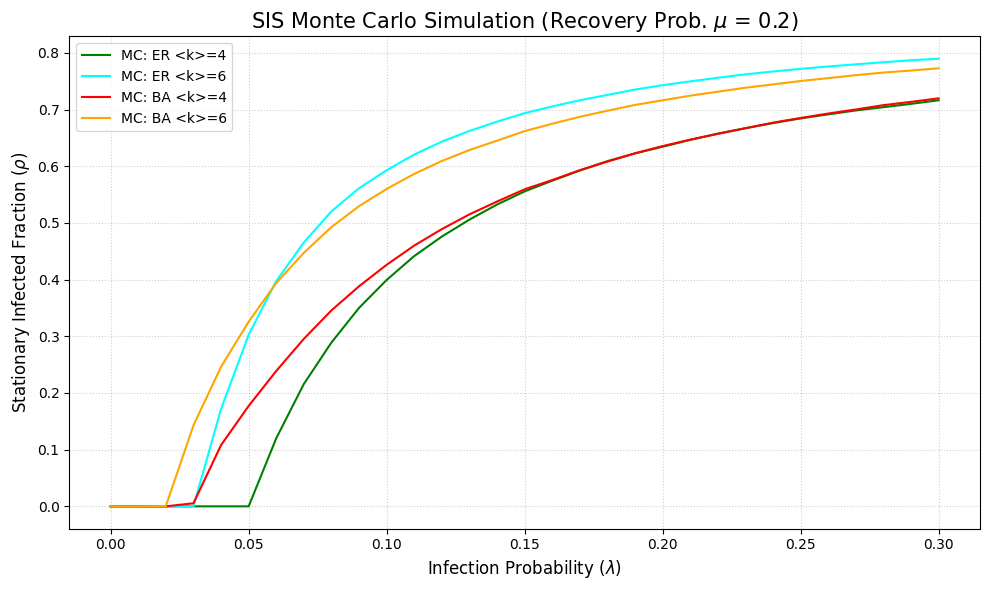

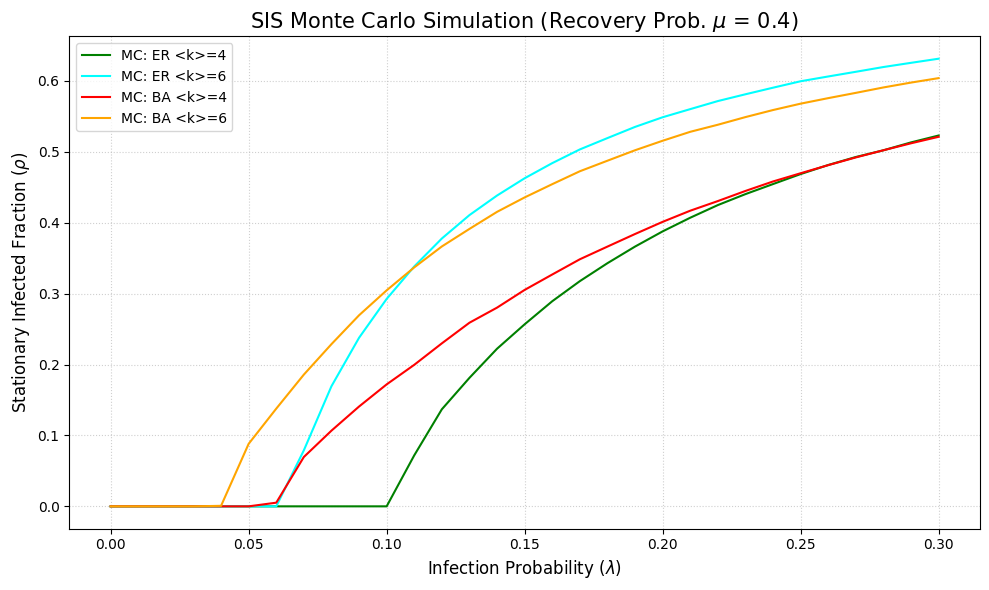

In [21]:
network_colors = {
    "ER <k>=4": "green",
    "ER <k>=6": "cyan",
    "BA <k>=4": "red",
    "BA <k>=6": "orange"
}
for mu in MUS:
    plt.figure(figsize=(10, 6))
    
    for name in nets:
        plt.plot(LAMBDAS, results_mc[mu][name], '-',
                 color=network_colors[name],
                 markersize=2, 
                 linewidth=1.5, 
                 label=f"MC: {name}")
    
    plt.title(f"SIS Monte Carlo Simulation (Recovery Prob. $\mu$ = {mu})", fontsize=15)
    plt.xlabel("Infection Probability ($\lambda$)", fontsize=12)
    plt.ylabel("Stationary Infected Fraction ($\\rho$)", fontsize=12)
    plt.legend(frameon=True, fontsize=10)
    plt.grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

Monte Carlo Simulation and MMCA comparison

<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\l'
/var/folders/y_/1f6tyxqn3hd98mt_8yc4vp0r0000gn/T/ipykernel_90370/3062678504.py:20: SyntaxWarning: invalid escape sequence '\m'
  plt.title(f"SIS Epidemic Diagram (Recovery Prob. $\mu$ = {mu})", fontsize=15)
/var/folders/y_/1f6tyxqn3hd98mt_8yc4vp0r0000gn/T/ipykernel_90370/3062678504.py:21: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel("Infection Probability ($\lambda$)", fontsize=12)


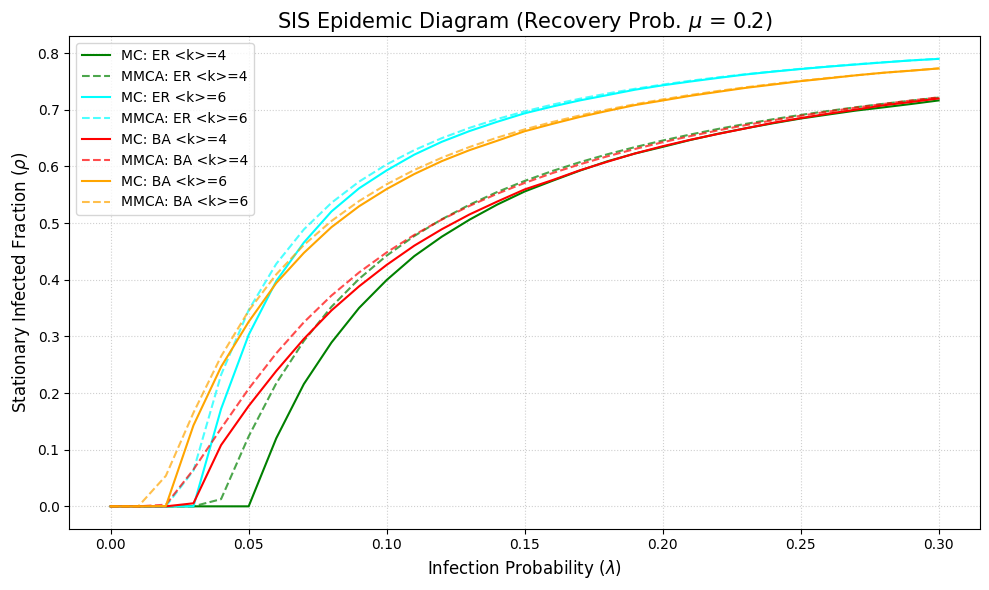

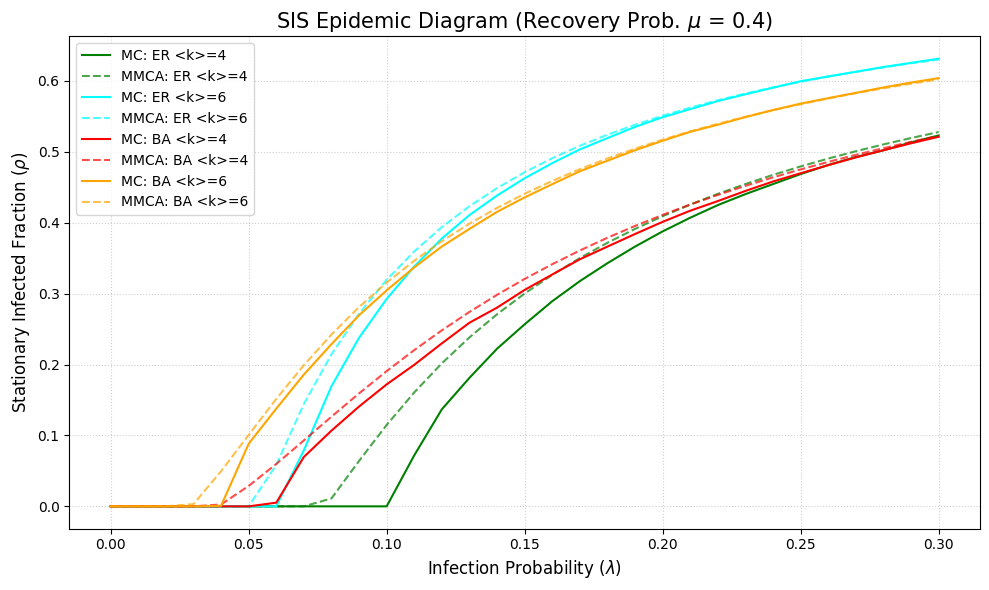

In [22]:

for mu in MUS:
    # Create a new figure for each mu
    plt.figure(figsize=(10, 6))
    
    for name in nets:
        # Plot MC Results as a solid line with dots
        line = plt.plot(LAMBDAS, results_mc[mu][name], '-', 
                        color=network_colors[name],
                        markersize=2, 
                        linewidth=1.5,
                        label=f"MC: {name}")
        color = line[0].get_color()
        
        # Plot MMCA Theory as a dashed line (matching color)
        plt.plot(LAMBDAS, results_theory[mu][name], '--', 
                 color=color, 
                 alpha=0.7, 
                 label=f"MMCA: {name}")
    
    plt.title(f"SIS Epidemic Diagram (Recovery Prob. $\mu$ = {mu})", fontsize=15)
    plt.xlabel("Infection Probability ($\lambda$)", fontsize=12)
    plt.ylabel("Stationary Infected Fraction ($\\rho$)", fontsize=12)
    plt.legend(frameon=True, fontsize=10)
    plt.grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()